In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Point to the new 10,000 row advanced dataset
PROJECT_ROOT = "E:/fdi-platform" 
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "synthetic", "synthetic_penalties_10k.csv")

df = pd.read_csv(DATA_PATH)

# Display the first 5 rows to confirm it loaded
df.head()

,player_penalty_conversion_rate,career_penalty_attempts,recent_penalty_form,is_shootout,match_stage,minute_of_match,team_pressure_state,run_up_style,pause_before_shot,shot_telegraph_level,...,keeper_experience_level,shot_direction,shot_height,corner_precision,goalkeeper_dive_direction,gk_correct_guess,reaction_time_ms,shooter_vs_keeper_history,psychological_advantage_index,is_goal
0,0.799671,17,0.505137,1,Group,113,Winning,Stutter,0,2,...,5,Right,Middle,0.635409,Center,0.0,263.058530,0,86,1
1,0.736174,12,0.713090,0,Group,116,Drawing,Curved,0,1,...,2,Left,Low,0.904600,Center,0.0,169.567845,0,17,1
2,0.814769,21,0.640312,1,Group,49,Drawing,Curved,0,2,...,3,Left,Low,0.830493,Center,0.0,192.718867,0,29,0
3,0.902303,18,0.667482,1,Group,43,Winning,Straight,0,3,...,4,Center,Low,0.658868,Center,0.0,273.271642,0,80,1
4,0.726585,17,0.703882,1,Group,68,Drawing,Straight,0,2,...,1,Left,Low,0.725316,Center,1.0,225.517571,0,51,1


In [2]:
print(f"Total penalties: {len(df)}")
print(f"Overall Conversion Rate: {df['is_goal'].mean() * 100:.1f}%\n")

print("--- Goalkeeper Impact ---")
print("Conversion Rate: GK Guess Correct vs Wrong")
print(df.groupby('gk_correct_guess')['is_goal'].mean() * 100)

Total penalties: 10000
Overall Conversion Rate: 65.8%

--- Goalkeeper Impact ---
Conversion Rate: GK Guess Correct vs Wrong
gk_correct_guess
0.0    88.713063
1.0    28.421329
Name: is_goal, dtype: float64


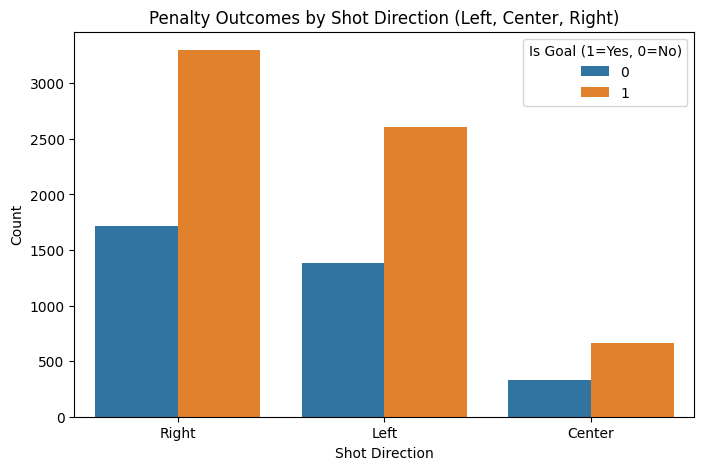

In [3]:
plt.figure(figsize=(8, 5))

# Plot where players place the ball and whether it results in a goal
sns.countplot(data=df, x='shot_direction', hue='is_goal')
plt.title('Penalty Outcomes by Shot Direction (Left, Center, Right)')
plt.xlabel('Shot Direction')
plt.ylabel('Count')
plt.legend(title='Is Goal (1=Yes, 0=No)')
plt.show()

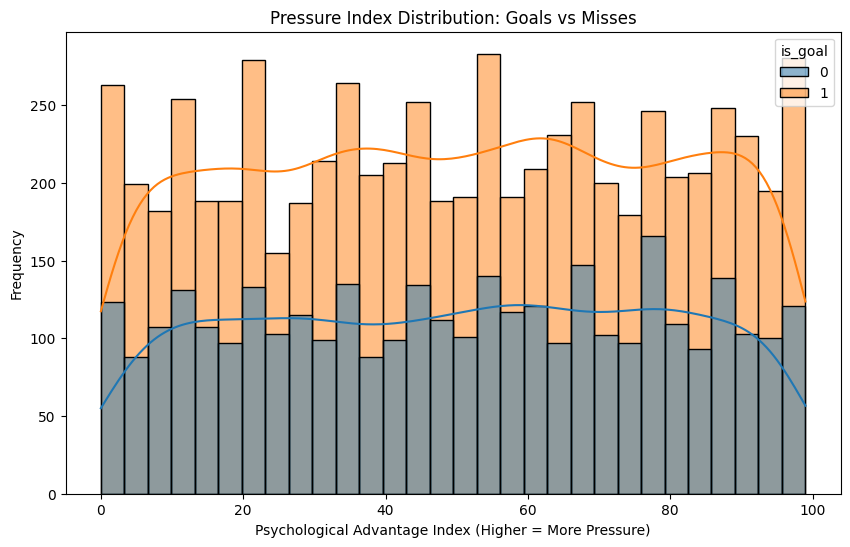

In [4]:
plt.figure(figsize=(10, 6))

# Plot how psychological pressure affects scoring
sns.histplot(data=df, x='psychological_advantage_index', hue='is_goal', kde=True, bins=30)
plt.title('Pressure Index Distribution: Goals vs Misses')
plt.xlabel('Psychological Advantage Index (Higher = More Pressure)')
plt.ylabel('Frequency')
plt.show()